CELDA1CELDA 1 — CARGA Y LIMPIEZA INICIAL

In [1]:
import pandas as pd
import numpy as np

# ==========================================
# 1. RUTAS DE ENTRADA
# ==========================================
ruta_resultado_final = '/content/resultado_final.csv'
ruta_history_aula2 = '/content/History_2025-09-01_100-2026-03-02_1400.csv'

# ==========================================
# 2. CARGA DE DATOS
# ==========================================
df_raw = pd.read_csv(
    ruta_resultado_final,
    low_memory=False,
    skiprows=[101383],
    on_bad_lines='warn'
)

hist = pd.read_csv(
    ruta_history_aula2,
    on_bad_lines='warn'
)

# ==========================================
# 3. LIMPIEZA BÁSICA
# ==========================================
df_raw.columns = [c.strip() for c in df_raw.columns]
hist.columns = [c.strip() for c in hist.columns]

df_raw['time'] = pd.to_datetime(df_raw['time'], errors='coerce', format='mixed')
df_raw['state_num'] = pd.to_numeric(df_raw['state'], errors='coerce')

df_raw = df_raw.dropna(subset=['time', 'entity_id']).sort_values('time')

print("Carga completada.")
print(f"Filas df_raw: {len(df_raw)}")
print(f"Filas hist: {len(hist)}")
print("\nPrimeras columnas df_raw:")
print(df_raw.columns.tolist()[:15])
print("\nPrimeras columnas hist:")
print(hist.columns.tolist())

Carga completada.
Filas df_raw: 949234
Filas hist: 4382

Primeras columnas df_raw:
['time', 'entity_id', 'state', 'attributes', 'state_num']

Primeras columnas hist:
['date', 'time', 'temperature ℃', 'humidity %RH']


CELDA 2 — RECONSTRUCCIÓN DE TEMPERATURA DEL AULA 2


In [2]:
# ==========================================
# 1. SENSORES DE TEMPERATURA AULA 1
# ==========================================
sensores_temp_aula1 = [
    'sensor.sensor_temperatura_1_temperature',
    'sensor.sensor_temperatura_2_temperature',
    'sensor.sensor_temperatura_3_temperature',
    'sensor.sensor_temperatura_4_temperature',
    'sensor.sensor_temperatura_3_nuevo_4_temperature'
]

# ==========================================
# 2. TEMPERATURA AULA 1 LIMPIA Y HORARIA
# ==========================================
df_temp_ref = df_raw[df_raw['entity_id'].isin(sensores_temp_aula1)].copy()

# rango físico razonable para aula interior
df_temp_ref = df_temp_ref[
    (df_temp_ref['state_num'] > 0) &
    (df_temp_ref['state_num'] < 50)
].copy()

df_temp_ref['datetime'] = df_temp_ref['time'].dt.floor('h')

df_aula1_temp = (
    df_temp_ref.groupby('datetime')['state_num']
    .mean()
    .to_frame('temp_aula1')
)

# ==========================================
# 3. TEMPERATURA AULA 2 DESDE HISTORY
# ==========================================
hist['datetime'] = pd.to_datetime(
    hist['date'].astype(str).str.replace('.', '-', regex=False) + ' ' + hist['time'].astype(str),
    errors='coerce'
)

hist['temp_aula2'] = pd.to_numeric(hist['temperature ℃'], errors='coerce')

df_aula2_temp = (
    hist.set_index('datetime')[['temp_aula2']]
    .resample('h')
    .mean()
)

# ==========================================
# 4. CÁLCULO DEL SESGO REAL
# ==========================================
df_comparacion_temp = pd.merge(
    df_aula1_temp,
    df_aula2_temp,
    left_index=True,
    right_index=True,
    how='inner'
).dropna()

if len(df_comparacion_temp) > 0:
    diferencia_temp_aula2 = (
        df_comparacion_temp['temp_aula2'] - df_comparacion_temp['temp_aula1']
    ).mean()
    print(f"Diferencia media Aula2 - Aula1: {diferencia_temp_aula2:.2f} °C")
else:
    diferencia_temp_aula2 = 0.0
    print("No hubo solape suficiente. Se usará diferencia 0.0 °C")

# ==========================================
# 5. RECONSTRUCCIÓN AULA 2
# ==========================================
df_final_temp = pd.merge(
    df_aula1_temp,
    df_aula2_temp,
    left_index=True,
    right_index=True,
    how='outer'
)

df_final_temp['temp_aula2_completada'] = df_final_temp['temp_aula2'].fillna(
    df_final_temp['temp_aula1'] + diferencia_temp_aula2
)

# nos quedamos con horas donde al menos existe referencia del aula 1
df_final_temp = df_final_temp.dropna(subset=['temp_aula1']).copy()

# ==========================================
# 6. GUARDAR
# ==========================================
df_final_temp.to_csv('TEMPERATURAS_AULA2.csv')

print("Archivo guardado: TEMPERATURAS_AULA2.csv")
display(df_final_temp.head(10))

Diferencia media Aula2 - Aula1: 1.41 °C
Archivo guardado: TEMPERATURAS_AULA2.csv


,temp_aula1,temp_aula2,temp_aula2_completada
datetime,,,
2024-12-10 19:00:00,21.150000,NaN,22.556923
2024-12-10 20:00:00,21.166000,NaN,22.572923
2024-12-10 21:00:00,20.474286,NaN,21.881209
2024-12-10 22:00:00,19.646000,NaN,21.052923
2024-12-10 23:00:00,19.353333,NaN,20.760257
2024-12-11 00:00:00,19.173333,NaN,20.580257
2024-12-11 01:00:00,18.952500,NaN,20.359423
2024-12-11 02:00:00,18.613333,NaN,20.020257
2024-12-11 03:00:00,18.530000,NaN,19.936923


 CELDA 3 — COMPROBACIONES Y GRÁFICO DE TEMPERATURA

Últimos registros:


,temp_aula1,temp_aula2,temp_aula2_completada
datetime,,,
2026-03-02 00:00:00,18.652222,20.4,20.4
2026-03-02 01:00:00,18.573846,20.3,20.3
2026-03-02 02:00:00,18.490000,20.3,20.3
2026-03-02 03:00:00,18.487647,20.3,20.3
2026-03-02 04:00:00,18.396364,20.2,20.2
2026-03-02 05:00:00,18.388333,20.2,20.2
2026-03-02 06:00:00,18.313750,20.2,20.2
2026-03-02 07:00:00,18.702222,20.2,20.2
2026-03-02 08:00:00,20.089545,20.5,20.5


Rango temporal: 2024-12-10 19:00:00 --> 2026-03-02 09:00:00


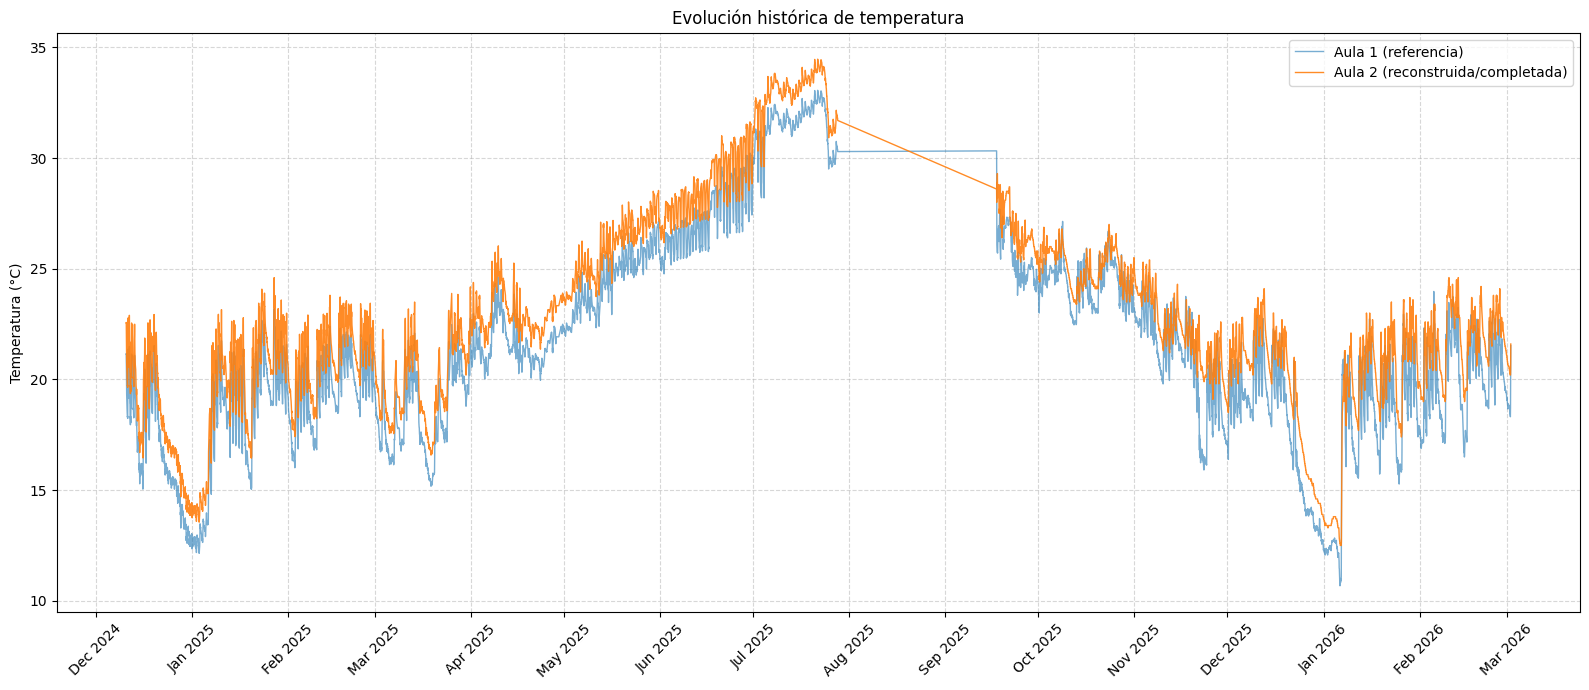

Registros por año:
datetime
2024     509
2025    7474
2026    1450
Name: count, dtype: int64


In [4]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("Últimos registros:")
display(df_final_temp.tail(10))

print(f"Rango temporal: {df_final_temp.index.min()} --> {df_final_temp.index.max()}")

plt.figure(figsize=(16, 7))

plt.plot(
    df_final_temp.index,
    df_final_temp['temp_aula1'],
    label='Aula 1 (referencia)',
    alpha=0.6,
    linewidth=1
)

plt.plot(
    df_final_temp.index,
    df_final_temp['temp_aula2_completada'],
    label='Aula 2 (reconstruida/completada)',
    alpha=0.9,
    linewidth=1
)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)

plt.title('Evolución histórica de temperatura')
plt.ylabel('Temperatura (°C)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("Registros por año:")
print(df_final_temp.index.year.value_counts().sort_index())

CELDA 4 — RECONSTRUCCIÓN DE HUMEDAD DEL AULA 2

In [5]:
# ==========================================
# 1. LISTA DE SENSORES DE HUMEDAD AULA 1
# ==========================================
sensores_hum_aula1 = [
    s for s in df_raw['entity_id'].dropna().unique()
    if 'humidity' in s.lower() and 'device' not in s.lower()
]

print("Sensores de humedad detectados:")
print(sensores_hum_aula1)

# ==========================================
# 2. HUMEDAD AULA 1 LIMPIA Y HORARIA
# ==========================================
df_hum_ref = df_raw[df_raw['entity_id'].isin(sensores_hum_aula1)].copy()

df_hum_ref = df_hum_ref[
    (df_hum_ref['state_num'] >= 0) &
    (df_hum_ref['state_num'] <= 100)
].copy()

df_hum_ref['datetime'] = df_hum_ref['time'].dt.floor('h')

df_aula1_hum = (
    df_hum_ref.groupby('datetime')['state_num']
    .mean()
    .to_frame('hum_aula1')
)

# ==========================================
# 3. HUMEDAD AULA 2 DESDE HISTORY
# ==========================================
hist['hum_aula2'] = pd.to_numeric(hist['humidity %RH'], errors='coerce')

df_aula2_hum = (
    hist.set_index('datetime')[['hum_aula2']]
    .resample('h')
    .mean()
)

# ==========================================
# 4. CÁLCULO DEL SESGO REAL
# ==========================================
df_comparacion_hum = pd.merge(
    df_aula1_hum,
    df_aula2_hum,
    left_index=True,
    right_index=True,
    how='inner'
).dropna()

if len(df_comparacion_hum) > 0:
    diferencia_hum_aula2 = (
        df_comparacion_hum['hum_aula2'] - df_comparacion_hum['hum_aula1']
    ).mean()
    print(f"Diferencia media humedad Aula2 - Aula1: {diferencia_hum_aula2:.2f} puntos")
else:
    diferencia_hum_aula2 = 0.0
    print("No hubo solape suficiente. Se usará diferencia 0.0")

# ==========================================
# 5. RECONSTRUCCIÓN AULA 2
# ==========================================
df_final_hum = pd.merge(
    df_aula1_hum,
    df_aula2_hum,
    left_index=True,
    right_index=True,
    how='outer'
)

df_final_hum['hum_aula2_completada'] = df_final_hum['hum_aula2'].fillna(
    df_final_hum['hum_aula1'] + diferencia_hum_aula2
)

df_final_hum['hum_aula2_completada'] = df_final_hum['hum_aula2_completada'].clip(0, 100)

df_final_hum.to_csv('HUMEDAD_AULA2.csv')

print("Archivo guardado: HUMEDAD_AULA2.csv")
display(df_final_hum.head(10))


Sensores de humedad detectados:
['sensor.sensor_temperatura_1_humidity', 'sensor.0x00158d000ae1b025_humidity', 'sensor.sensor_temperatura_22_humidity', 'sensor.sensor_temperatura_2_humidity', 'sensor.manises_valencia_humidity', 'sensor.manises_valencia_daily_max_humidity', 'sensor.manises_valencia_daily_min_humidity', 'sensor.0x00158d000ae469dd_humidity', 'sensor.sensor_temperatura_3_humidity', 'sensor.0x00158d000ad80141_humidity', 'sensor.sensor_temperatura_4_humidity', 'sensor.sensor_temperatura_3_nuevo_4_humidity']
Diferencia media humedad Aula2 - Aula1: -1.21 puntos
Archivo guardado: HUMEDAD_AULA2.csv


,hum_aula1,hum_aula2,hum_aula2_completada
datetime,,,
2024-12-10 19:00:00,46.720000,NaN,45.510221
2024-12-10 20:00:00,53.728333,NaN,52.518554
2024-12-10 21:00:00,52.526667,NaN,51.316887
2024-12-10 22:00:00,51.407143,NaN,50.197363
2024-12-10 23:00:00,53.930000,NaN,52.720221
2024-12-11 00:00:00,68.890000,NaN,67.680221
2024-12-11 01:00:00,67.195000,NaN,65.985221
2024-12-11 02:00:00,66.560000,NaN,65.350221
2024-12-11 03:00:00,53.026000,NaN,51.816221


CELDA 5 — GRÁFICO DE HUMEDAD


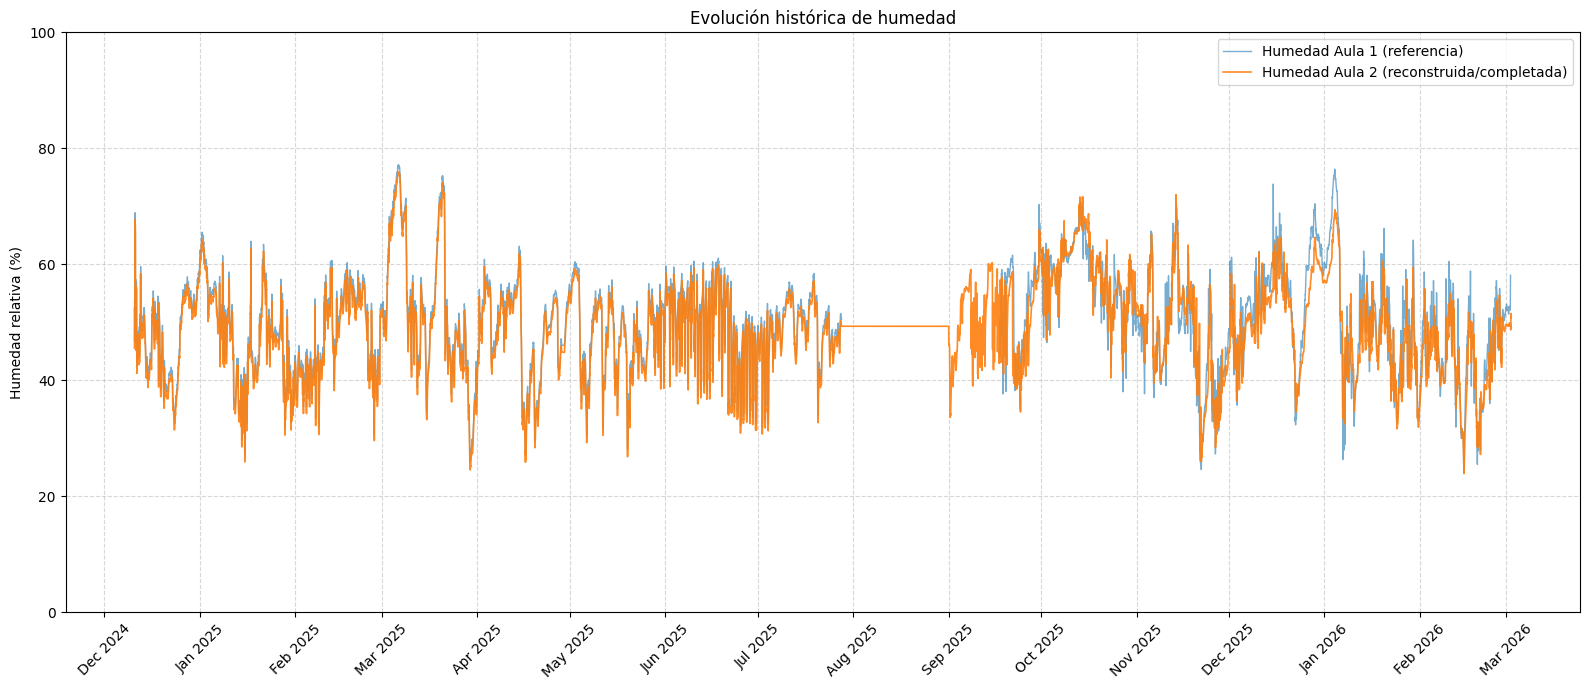

Archivo guardado: comparativa_humedad_final.csv


In [6]:
plt.figure(figsize=(16, 7))

plt.plot(
    df_final_hum.index,
    df_final_hum['hum_aula1'],
    label='Humedad Aula 1 (referencia)',
    alpha=0.6,
    linewidth=1
)

plt.plot(
    df_final_hum.index,
    df_final_hum['hum_aula2_completada'],
    label='Humedad Aula 2 (reconstruida/completada)',
    alpha=0.9,
    linewidth=1.2
)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)

plt.title('Evolución histórica de humedad')
plt.ylabel('Humedad relativa (%)')
plt.ylim(0, 100)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

df_final_hum.reset_index().to_csv('comparativa_humedad_final.csv', index=False)
print("Archivo guardado: comparativa_humedad_final.csv")

 CELDA 6 — CONSTRUCCIÓN DEL DATAFRAME HORARIO BASE


In [7]:
# ==========================================
# 1. FEATURES TEMPORALES
# ==========================================
df_base_horaria = pd.DataFrame(index=df_final_temp.index.copy())
df_base_horaria['hora'] = df_base_horaria.index.hour
df_base_horaria['dia_semana'] = df_base_horaria.index.weekday
df_base_horaria['mes'] = df_base_horaria.index.month

# ==========================================
# 2. VARIABLES PRINCIPALES RECONSTRUIDAS
# ==========================================
df_base_horaria = df_base_horaria.merge(
    df_final_temp[['temp_aula1', 'temp_aula2_completada']],
    left_index=True,
    right_index=True,
    how='left'
)

df_base_horaria = df_base_horaria.merge(
    df_final_hum[['hum_aula1', 'hum_aula2_completada']],
    left_index=True,
    right_index=True,
    how='left'
)

# ==========================================
# 3. OTRAS FEATURES NUMÉRICAS DE SENSORES Y EXTERNAS
# ==========================================
df_sensors = df_raw.copy()

df_pivot_h = df_sensors.pivot_table(
    index=pd.Grouper(key='time', freq='h'),
    columns='entity_id',
    values='state_num',
    aggfunc='mean'
)

# columnas que pueden aportar valor al modelo
columnas_interes = [
    c for c in df_pivot_h.columns
    if any(txt in c.lower() for txt in [
        'temperature',
        'humidity',
        'pressure',
        'cloud',
        'sun',
        'elevation',
        'azimuth',
        'outdoor',
        'weather'
    ])
]

df_base_horaria = df_base_horaria.merge(
    df_pivot_h[columnas_interes],
    left_index=True,
    right_index=True,
    how='left'
)

print("DataFrame horario base creado.")
print(f"Filas: {len(df_base_horaria)}")
print(f"Columnas: {len(df_base_horaria.columns)}")
display(df_base_horaria.head(5))


DataFrame horario base creado.
Filas: 9433
Columnas: 55


,hora,dia_semana,mes,temp_aula1,temp_aula2_completada,hum_aula1,hum_aula2_completada,sensor.0x00158d000ad80141_humidity,sensor.0x00158d000ad80141_pressure,sensor.0x00158d000ad80141_temperature,...,sensor.sensor_ventana_2_device_temperature,sensor.sensor_ventana_3_device_temperature,sensor.sensor_ventana_4_device_temperature,sensor.sensor_ventana_5_device_temperature,sensor.sensor_ventana_6_device_temperature,sensor.sensor_ventana_7_device_temperature,sensor.sensor_ventana_8_device_temperature,sensor.sensor_ventana_9_device_temperature,sensor.sun_solar_azimuth,sensor.sun_solar_elevation
datetime,,,,,,,,,,,,,,,,,,,,,
2024-12-10 19:00:00,19,1,12,21.150000,22.556923,46.720000,45.510221,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-12-10 20:00:00,20,1,12,21.166000,22.572923,53.728333,52.518554,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-12-10 21:00:00,21,1,12,20.474286,21.881209,52.526667,51.316887,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-12-10 22:00:00,22,1,12,19.646000,21.052923,51.407143,50.197363,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-12-10 23:00:00,23,1,12,19.353333,20.760257,53.930000,52.720221,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


CELDA 7 — ALGORITMO DE CALEFACCIÓN ENCENDIDA

In [8]:
# ==========================================
# 1. FUNCIÓN DE REGLAS DE CALEFACCIÓN
# ==========================================
def calcular_calefaccion_on(row):
    dt = row.name
    temp = row['temp_aula2_completada']

    if pd.isna(temp):
        return 0

    # solo de lunes a viernes
    if dt.weekday() > 4:
        return 0

    h = dt.hour

    # franjas 1, 2 y 4
    if (7 <= h < 11) or (11 <= h < 16) or (18 <= h < 21):
        return 1 if temp < 21.95 else 0

    # franja 3
    if 16 <= h < 18:
        return 1 if temp < 21.55 else 0

    return 0

# ==========================================
# 2. APLICACIÓN
# ==========================================
df_base_horaria['calefaccion_actual'] = df_base_horaria.apply(calcular_calefaccion_on, axis=1)

# ==========================================
# 3. GUARDAR
# ==========================================
df_base_horaria.to_csv('RESULTADO_CON_CALEFACCION.csv')

print("Archivo guardado: RESULTADO_CON_CALEFACCION.csv")
print(f"Horas con calefacción encendida: {df_base_horaria['calefaccion_actual'].sum()}")
display(df_base_horaria[['temp_aula2_completada', 'calefaccion_actual']].head(20))

Archivo guardado: RESULTADO_CON_CALEFACCION.csv
Horas con calefacción encendida: 1352


,temp_aula2_completada,calefaccion_actual
datetime,,
2024-12-10 19:00:00,22.556923,0
2024-12-10 20:00:00,22.572923,0
2024-12-10 21:00:00,21.881209,0
2024-12-10 22:00:00,21.052923,0
2024-12-10 23:00:00,20.760257,0
2024-12-11 00:00:00,20.580257,0
2024-12-11 01:00:00,20.359423,0
2024-12-11 02:00:00,20.020257,0
2024-12-11 03:00:00,19.936923,0


CELDA 8 — CÁLCULO DE APERTURAS PONDERADAS

In [9]:
# ==========================================
# 1. DETECCIÓN DE SENSORES DE CONTACTO
# ==========================================
sensores_contacto = [
    s for s in df_raw['entity_id'].dropna().unique()
    if (
        ('contact' in s.lower() or 'puerta' in s.lower() or 'ventana' in s.lower())
        and 'temperature' not in s.lower()
        and 'battery' not in s.lower()
        and 'device' not in s.lower()
    )
]

print("Sensores de contacto detectados:")
print(sensores_contacto)

# ==========================================
# 2. DATOS DE APERTURA
# ==========================================
df_contact = df_raw[df_raw['entity_id'].isin(sensores_contacto)].copy()

df_contact['is_open'] = (
    df_contact['state']
    .astype(str)
    .str.strip()
    .str.lower()
    .map({'on': 1, 'off': 0, 'open': 1, 'closed': 0})
)

df_contact['is_open'] = df_contact['is_open'].fillna(0)

# ==========================================
# 3. PIVOT Y REMUESTREO A MINUTO
# ==========================================
df_contact_pivot = df_contact.pivot_table(
    index='time',
    columns='entity_id',
    values='is_open',
    aggfunc='max'
)

df_contact_minuto = df_contact_pivot.resample('1min').ffill(limit=60).fillna(0)

# ==========================================
# 4. PONDERACIÓN SEGÚN ENUNCIADO
#    - ventana superior/pequeña = 1
#    - ventana inferior/grande = 2
#    - puerta = 4
# ==========================================
for col in df_contact_minuto.columns:
    nombre = col.lower()

    if 'puerta' in nombre:
        peso = 4
    elif 'grande' in nombre or 'inferior' in nombre:
        peso = 2
    else:
        peso = 1

    df_contact_minuto[col] = df_contact_minuto[col] * peso

# ==========================================
# 5. ÍNDICE HORARIO DE APERTURA PONDERADA
# ==========================================
indice_apertura_hora = df_contact_minuto.sum(axis=1).resample('h').sum()

df_base_horaria = df_base_horaria.merge(
    indice_apertura_hora.to_frame('indice_apertura_ponderado'),
    left_index=True,
    right_index=True,
    how='left'
)

df_base_horaria['indice_apertura_ponderado'] = df_base_horaria['indice_apertura_ponderado'].fillna(0)

print("Índice de apertura ponderado calculado.")
display(df_base_horaria[['indice_apertura_ponderado']].head(20))


Sensores de contacto detectados:
['binary_sensor.0x00158d000ae116d1_contact', 'binary_sensor.sensor_ventana_1_contact', 'binary_sensor.0x00158d000ae0ff7f_contact', 'binary_sensor.sensor_ventana_2_contact', 'binary_sensor.0x00158d000ae18e5d_contact', 'binary_sensor.sensor_ventana_3_contact', 'binary_sensor.0x00158d000ae11566_contact', 'binary_sensor.sensor_ventana_4_contact', 'binary_sensor.0x00158d000ae10102_contact', 'binary_sensor.sensor_ventana_5_contact', 'binary_sensor.0x00158d000ae16a5e_contact', 'binary_sensor.sensor_ventana_6_contact', 'binary_sensor.0x00158d000ae10073_contact', 'binary_sensor.sensor_ventana_7_contact', 'binary_sensor.0x00158d000ae145b3_contact', 'binary_sensor.sensor_ventana_8_contact', 'binary_sensor.0x00158d000ae15575_contact', 'binary_sensor.sensor_ventana_9_contact', 'binary_sensor.0x00158d000ae10022_contact', 'binary_sensor.sensor_ventana_10_contact', 'binary_sensor.0x00158d000ae14637_contact', 'binary_sensor.sensor_ventana_11_contact', 'binary_sensor.0x0

,indice_apertura_ponderado
datetime,
2024-12-10 19:00:00,0.0
2024-12-10 20:00:00,0.0
2024-12-10 21:00:00,0.0
2024-12-10 22:00:00,0.0
2024-12-10 23:00:00,0.0
2024-12-11 00:00:00,0.0
2024-12-11 01:00:00,0.0
2024-12-11 02:00:00,0.0
2024-12-11 03:00:00,0.0


CELDA 9 — CÁLCULO DE DERROCHE ACTUAL

In [10]:
# ==========================================
# 1. UMBRAL DE DERROCHE
# ==========================================
UMBRAL_DERROCHE = 20

# ==========================================
# 2. DERROCHE ACTUAL
# ==========================================
df_base_horaria['hay_derroche'] = (
    (df_base_horaria['calefaccion_actual'] == 1) &
    (df_base_horaria['indice_apertura_ponderado'] >= UMBRAL_DERROCHE)
).astype(int)

# ==========================================
# 3. GUARDAR
# ==========================================
df_base_horaria.to_csv('DATASET_CON_DERROCHE_ACTUAL.csv')

print("Archivo guardado: DATASET_CON_DERROCHE_ACTUAL.csv")
print(f"Horas con derroche detectado: {df_base_horaria['hay_derroche'].sum()}")

display(
    df_base_horaria[
        ['temp_aula2_completada', 'calefaccion_actual', 'indice_apertura_ponderado', 'hay_derroche']
    ].head(20)
)

Archivo guardado: DATASET_CON_DERROCHE_ACTUAL.csv
Horas con derroche detectado: 367


,temp_aula2_completada,calefaccion_actual,indice_apertura_ponderado,hay_derroche
datetime,,,,
2024-12-10 19:00:00,22.556923,0,0.0,0
2024-12-10 20:00:00,22.572923,0,0.0,0
2024-12-10 21:00:00,21.881209,0,0.0,0
2024-12-10 22:00:00,21.052923,0,0.0,0
2024-12-10 23:00:00,20.760257,0,0.0,0
2024-12-11 00:00:00,20.580257,0,0.0,0
2024-12-11 01:00:00,20.359423,0,0.0,0
2024-12-11 02:00:00,20.020257,0,0.0,0
2024-12-11 03:00:00,19.936923,0,0.0,0


CELDA 10 — GRÁFICO DE DERROCHE DIARIO

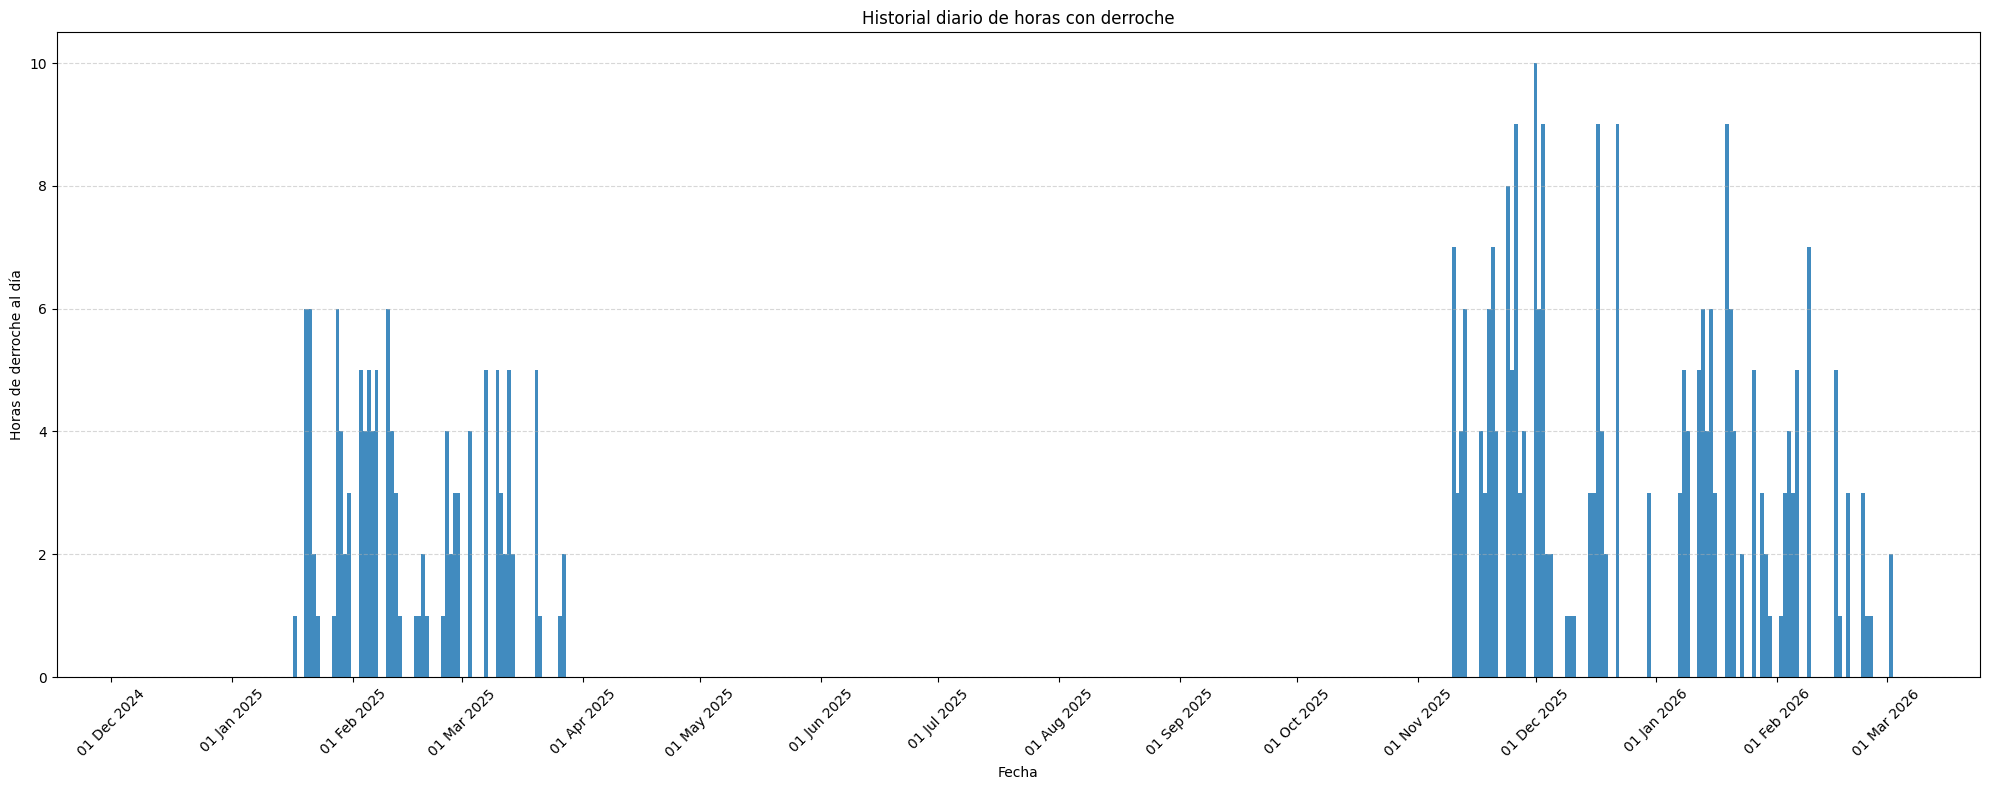

Horas totales con derroche: 367

Distribución de clases:
hay_derroche
0    9066
1     367
Name: count, dtype: int64

Resumen del índice de apertura ponderado:
count    9433.000000
mean        9.184671
std        29.485420
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       240.000000
Name: indice_apertura_ponderado, dtype: float64


In [11]:
derroche_diario = df_base_horaria['hay_derroche'].resample('D').sum()

plt.figure(figsize=(20, 8))
plt.bar(derroche_diario.index, derroche_diario, alpha=0.85, width=1.0)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)

plt.title('Historial diario de horas con derroche')
plt.ylabel('Horas de derroche al día')
plt.xlabel('Fecha')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Horas totales con derroche: {df_base_horaria['hay_derroche'].sum()}")
print("\nDistribución de clases:")
print(df_base_horaria['hay_derroche'].value_counts())
print("\nResumen del índice de apertura ponderado:")
print(df_base_horaria['indice_apertura_ponderado'].describe())

CELDA 11 — CREACIÓN DEL TARGET A UNA HORA VISTA

In [12]:
# ==========================================
# 1. TARGET: DERROCHE EN LA HORA SIGUIENTE
# ==========================================
df_base_horaria['TARGET_derroche_proxima_hora'] = df_base_horaria['hay_derroche'].shift(-1)

# ==========================================
# 2. ELIMINAR ÚLTIMA FILA SIN TARGET
# ==========================================
df_modelo = df_base_horaria.dropna(subset=['TARGET_derroche_proxima_hora']).copy()
df_modelo['TARGET_derroche_proxima_hora'] = df_modelo['TARGET_derroche_proxima_hora'].astype(int)

print("Target creado correctamente.")
print(df_modelo[['hay_derroche', 'TARGET_derroche_proxima_hora']].tail(10))

Target creado correctamente.
                     hay_derroche  TARGET_derroche_proxima_hora
datetime                                                       
2026-03-01 23:00:00             0                             0
2026-03-02 00:00:00             0                             0
2026-03-02 01:00:00             0                             0
2026-03-02 02:00:00             0                             0
2026-03-02 03:00:00             0                             0
2026-03-02 04:00:00             0                             0
2026-03-02 05:00:00             0                             0
2026-03-02 06:00:00             0                             1
2026-03-02 07:00:00             1                             1
2026-03-02 08:00:00             1                             0


CELDA 12 — DATASET FINAL PARA IA


In [13]:
from google.colab import files

# ==========================================
# 1. COLUMNAS A EXCLUIR DEL MODELO
# ==========================================
columnas_excluir = [
    'hay_derroche',                 # es la etiqueta actual, no queremos que ayude al target futuro
    'indice_apertura_ponderado'     # se usa para construir la etiqueta, la quitamos para evitar "aprender la fórmula"
]

# opcional: si quieres también quitar temp_aula1 o hum_aula1 duplicadas, lo decides aquí
df_ia_modelo = df_modelo.drop(columns=columnas_excluir, errors='ignore').copy()

# ==========================================
# 2. LIMPIEZA FINAL
# ==========================================
# solo forward fill para mantener coherencia temporal
df_ia_modelo = df_ia_modelo.ffill()

# quitar filas que sigan teniendo demasiados nulos
df_ia_modelo = df_ia_modelo.dropna().copy()

# ==========================================
# 3. EXPORTACIÓN
# ==========================================
nombre_dataset = 'DATASET_ENTRENAMIENTO_IA.csv'
df_ia_modelo.to_csv(nombre_dataset, index=False)
files.download(nombre_dataset)

print("Dataset final generado.")
print(f"Filas finales: {len(df_ia_modelo)}")
print("\nDistribución del target:")
print(df_ia_modelo['TARGET_derroche_proxima_hora'].value_counts())
print("\nColumnas finales:")
print(df_ia_modelo.columns.tolist())

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Dataset final generado.
Filas finales: 8423

Distribución del target:
TARGET_derroche_proxima_hora
0    8069
1     354
Name: count, dtype: int64

Columnas finales:
['hora', 'dia_semana', 'mes', 'temp_aula1', 'temp_aula2_completada', 'hum_aula1', 'hum_aula2_completada', 'sensor.0x00158d000ad80141_humidity', 'sensor.0x00158d000ad80141_pressure', 'sensor.0x00158d000ad80141_temperature', 'sensor.0x00158d000ae1b025_humidity', 'sensor.0x00158d000ae1b025_pressure', 'sensor.0x00158d000ae1b025_temperature', 'sensor.0x00158d000ae469dd_humidity', 'sensor.0x00158d000ae469dd_pressure', 'sensor.0x00158d000ae469dd_temperature', 'sensor.manises_valencia_daily_max_humidity', 'sensor.manises_valencia_daily_max_pressure', 'sensor.manises_valencia_daily_max_temperature', 'sensor.manises_valencia_daily_min_humidity', 'sensor.manises_valencia_daily_min_pressure', 'sensor.manises_valencia_daily_min_temperature', 'sensor.manises_valencia_humidity', 'sensor.manises_valencia_pressure', 'sensor.manises_valencia_

CELDA 13 — RED NEURONAL

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# ==========================================
# 1. CARGA DEL DATASET FINAL
# ==========================================
ruta_dataset = '/content/DATASET_ENTRENAMIENTO_IA.csv'
df_ia = pd.read_csv(ruta_dataset)

# ==========================================
# 2. PREPARACIÓN DE X E Y
# ==========================================
X = df_ia.drop(columns=['TARGET_derroche_proxima_hora'])
y = df_ia['TARGET_derroche_proxima_hora']

# ==========================================
# 3. DIVISIÓN TEMPORAL
# ==========================================
n_total = len(df_ia)
n_train = int(n_total * 0.70)
n_val = int(n_total * 0.15)

X_train = X.iloc[:n_train]
y_train = y.iloc[:n_train]

X_val = X.iloc[n_train:n_train + n_val]
y_val = y.iloc[n_train:n_train + n_val]

X_test = X.iloc[n_train + n_val:]
y_test = y.iloc[n_train + n_val:]

print(f"Train: {len(X_train)} filas")
print(f"Validación: {len(X_val)} filas")
print(f"Test: {len(X_test)} filas")

# ==========================================
# 4. ESCALADO
# ==========================================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 5. RED NEURONAL (CON MEJORAS)
# ==========================================
model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid') # Salida de probabilidad 0 a 1
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ==========================================
# 6. PESOS DE CLASE (AUMENTADO A 12.0)
# ==========================================
# Como hay pocos casos de derroche, forzamos a la red a que los busque
pesos_clase = {0: 1.0, 1: 12.0}

# ==========================================
# 7. EARLY STOPPING
# ==========================================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15, # Un poco más de paciencia para que aprenda el caso difícil
    restore_best_weights=True
)

# ==========================================
# 8. ENTRENAMIENTO
# ==========================================
history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    class_weight=pesos_clase, # <--- Clave para mejorar el 0%
    callbacks=[early_stop],
    verbose=0,
    shuffle=False
)

print("Entrenamiento completado con pesos ajustados.")

Train: 5896 filas
Validación: 1263 filas
Test: 1264 filas
Entrenamiento completado con pesos ajustados.


CELDA 14 — EVALUACIÓN DE LA RED NEURONAL

EVALUACIÓN FINAL CON AJUSTES
Exactitud (Accuracy):     90.35%
Precisión (Precision):   41.73%
Detección (Recall):      52.48%
Puntuación F1 (F1-score): 46.49%

Informe detallado (en %):


,precision,recall,f1-score
0,95.78%,93.64%,94.7%
1,41.73%,52.48%,46.49%
accuracy,90.35%,90.35%,90.35%
macro avg,68.76%,73.06%,70.59%
weighted avg,91.46%,90.35%,90.84%


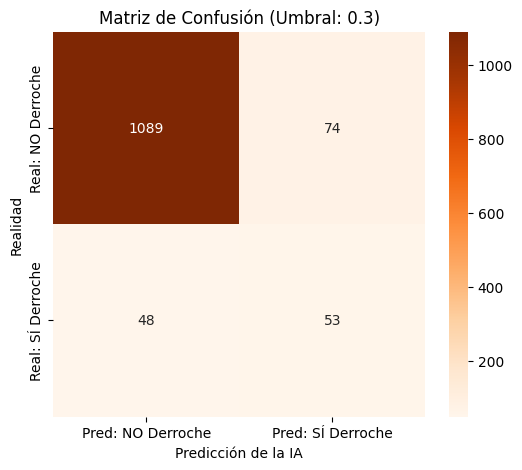

,Real,Prediccion,Probabilidad (%)
0,1,1,51.779999
1,0,1,52.540001
2,1,1,48.189999
3,0,1,44.520000
4,0,0,5.680000
5,0,0,6.020000
6,0,0,5.170000
7,0,0,3.860000
8,0,0,11.010000
9,0,0,10.710000


In [15]:
# ==========================================
# 1. IMPORTACIONES NECESARIAS (Evita NameError)
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  # <--- Esto es lo que faltaba
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score

# ==========================================
# 2. PREDICCIONES CON UMBRAL SENSIBLE (0.3)
# ==========================================
y_probs = model.predict(X_test_scaled, verbose=0).flatten()
umbral = 0.3
y_pred = (y_probs >= umbral).astype(int)

# ==========================================
# 3. MÉTRICAS EN PORCENTAJES
# ==========================================
accuracy = (y_pred == y_test.values).mean()
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("EVALUACIÓN FINAL CON AJUSTES")
print("=" * 40)
print(f"Exactitud (Accuracy):     {accuracy:.2%}")
print(f"Precisión (Precision):   {precision:.2%}")
print(f"Detección (Recall):      {recall:.2%}")
print(f"Puntuación F1 (F1-score): {f1:.2%}")

print("\nInforme detallado (en %):")
report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
df_report = pd.DataFrame(report_dict).transpose()
display((df_report.iloc[:, :3] * 100).round(2).astype(str) + '%')

# ==========================================
# 4. MATRIZ DE CONFUSIÓN VISUAL
# ==========================================
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Pred: NO Derroche', 'Pred: SÍ Derroche'],
            yticklabels=['Real: NO Derroche', 'Real: SÍ Derroche'])
plt.title(f'Matriz de Confusión (Umbral: {umbral})')
plt.xlabel('Predicción de la IA')
plt.ylabel('Realidad')
plt.show()

# ==========================================
# 5. TABLA COMPARATIVA (HEAD)
# ==========================================
comparativa = pd.DataFrame({
    'Real': y_test.values,
    'Prediccion': y_pred,
    'Probabilidad (%)': np.round(y_probs * 100, 2)
})
display(comparativa.head(10))

 CELDA 15 — GRÁFICAS DE ENTRENAMIENTO

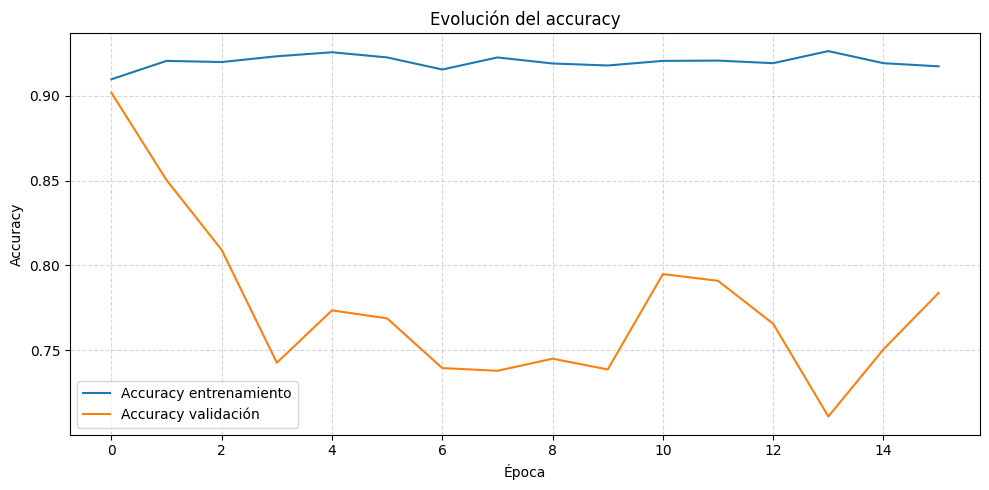

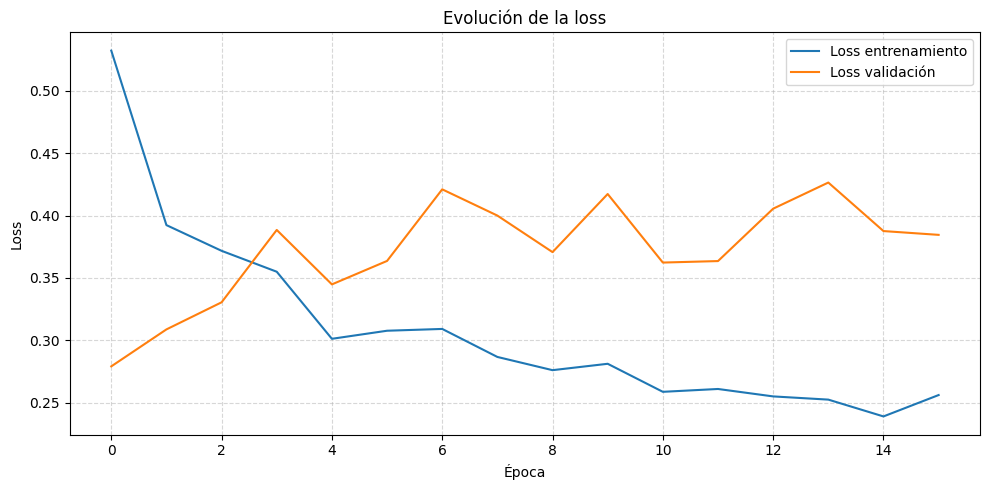

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Accuracy entrenamiento')
plt.plot(history.history['val_accuracy'], label='Accuracy validación')
plt.title('Evolución del accuracy')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Loss entrenamiento')
plt.plot(history.history['val_loss'], label='Loss validación')
plt.title('Evolución de la loss')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

CELDA 16 — GUARDAR MODELO, SCALER Y MÉTRICAS

In [18]:
import json
import joblib

# ==========================================
# 1. GUARDAR MODELO
# ==========================================
model.save('model_nn.keras')

# ==========================================
# 2. GUARDAR SCALER
# ==========================================
joblib.dump(scaler, 'scaler_nn.pkl')

# ==========================================
# 3. GUARDAR MÉTRICAS
# ==========================================
metricas = {
    'accuracy': float(accuracy),
    'precision': float(precision),
    'recall': float(recall),
    'f1_score': float(f1),
    'train_rows': int(len(X_train)),
    'val_rows': int(len(X_val)),
    'test_rows': int(len(X_test)),
    'columnas_modelo': list(X.columns)
}

with open('metrics_nn.json', 'w', encoding='utf-8') as f:
    json.dump(metricas, f, indent=4, ensure_ascii=False)

print("Artefactos guardados:")
print("- model_nn.keras")
print("- scaler_nn.pkl")
print("- metrics_nn.json")

Artefactos guardados:
- model_nn.keras
- scaler_nn.pkl
- metrics_nn.json


CELDA 17 — DESCARGA FINAL DE ARCHIVOS IMPORTANTES

In [ ]:
from google.colab import files

archivos_descargar = [
    'TEMPERATURAS_AULA2.csv',
    'HUMEDAD_AULA2.csv',
    'RESULTADO_CON_CALEFACCION.csv',
    'DATASET_CON_DERROCHE_ACTUAL.csv',
    'DATASET_ENTRENAMIENTO_IA.csv',
    'model_nn.keras',
    'scaler_nn.pkl',
    'metrics_nn.json'
]

for archivo in archivos_descargar:
    try:
        files.download(archivo)
        print(f"Descargado: {archivo}")
    except Exception as e:
        print(f"No se pudo descargar {archivo}: {e}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargado: TEMPERATURAS_AULA2.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Descargado: scaler_nn.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargado: metrics_nn.json


CELDA 18 — GRAFICA Y DEMOSTRACION DEL MACHINE LEARNING

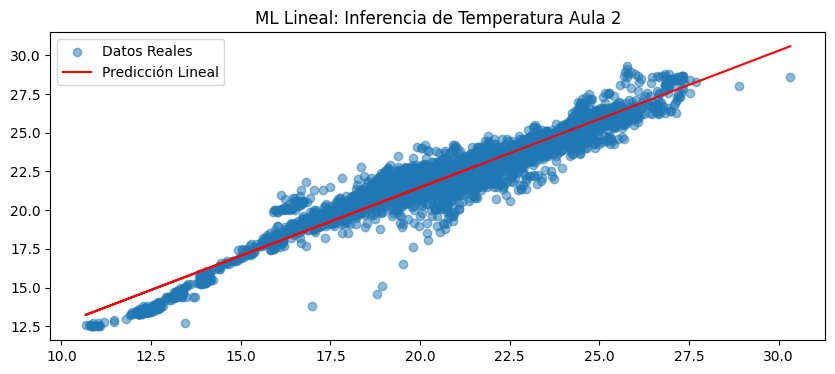

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from google.colab import files

ruta_resultado_final = '/content/resultado_final.csv'
ruta_history_aula2 = '/content/History_2025-09-01_100-2026-03-02_1400.csv'

df_raw = pd.read_csv(ruta_resultado_final, low_memory=False, skiprows=[101383], on_bad_lines='warn')
hist = pd.read_csv(ruta_history_aula2, on_bad_lines='warn')

df_raw.columns = [c.strip() for c in df_raw.columns]
hist.columns = [c.strip() for c in hist.columns]

df_raw['time'] = pd.to_datetime(df_raw['time'], errors='coerce', format='mixed')
df_raw['state_num'] = pd.to_numeric(df_raw['state'], errors='coerce')
df_raw = df_raw.dropna(subset=['time', 'entity_id']).sort_values('time')


sensores_temp_aula1 = ['sensor.sensor_temperatura_1_temperature','sensor.sensor_temperatura_2_temperature',
                       'sensor.sensor_temperatura_3_temperature','sensor.sensor_temperatura_4_temperature']

df_temp_ref = df_raw[df_raw['entity_id'].isin(sensores_temp_aula1)].copy()
df_temp_ref = df_temp_ref[(df_temp_ref['state_num'] > 0) & (df_temp_ref['state_num'] < 50)].copy()
df_temp_ref['datetime'] = df_temp_ref['time'].dt.floor('h')

df_aula1_temp = df_temp_ref.groupby('datetime')['state_num'].mean().to_frame('temp_aula1')

# Preparar History Aula 2
hist['datetime'] = pd.to_datetime(hist['date'].astype(str).str.replace('.', '-', regex=False) + ' ' + hist['time'].astype(str), errors='coerce')
hist['temp_aula2'] = pd.to_numeric(hist['temperature ℃'], errors='coerce')
df_aula2_temp = hist.set_index('datetime')[['temp_aula2']].resample('h').mean()

# Entrenamiento de Regresión Lineal (Sesgo Real)
df_comparacion = pd.merge(df_aula1_temp, df_aula2_temp, left_index=True, right_index=True, how='inner').dropna()
mod_lin = LinearRegression()
X_reg = df_comparacion[['temp_aula1']].values
y_reg = df_comparacion['temp_aula2'].values
mod_lin.fit(X_reg, y_reg)

# Reconstrucción de datos
df_final_temp = pd.merge(df_aula1_temp, df_aula2_temp, left_index=True, right_index=True, how='outer')
df_final_temp['temp_aula2_completada'] = df_final_temp['temp_aula2'].fillna(
    pd.Series(mod_lin.predict(df_final_temp[['temp_aula1']].fillna(0).values).flatten(), index=df_final_temp.index)
)
df_final_temp = df_final_temp.dropna(subset=['temp_aula1']).copy()

# GRÁFICA ML LINEAL
plt.figure(figsize=(10, 4))
plt.scatter(X_reg, y_reg, alpha=0.5, label='Datos Reales')
plt.plot(X_reg, mod_lin.predict(X_reg), color='red', label='Predicción Lineal')
plt.title('ML Lineal: Inferencia de Temperatura Aula 2')
plt.legend()
plt.show()


In [20]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np

st.set_page_config(page_title="IA Auditoría Energética", page_icon="🏫")

st.title("🛡️ Sistema de Predicción de Derroche")
st.markdown("Introduce los valores de los sensores para saber si habrá derroche en la **próxima hora**.")

# Formulario de entrada
with st.form("my_form"):
    col1, col2 = st.columns(2)

    with col1:
        hora = st.slider("Hora del día", 0, 23, 12)
        temp = st.number_input("Temperatura Aula 1 (°C)", 10.0, 35.0, 21.5)
        hum = st.number_input("Humedad Aula 1 (%)", 0.0, 100.0, 45.0)

    with col2:
        mes = st.selectbox("Mes", range(1, 13), index=2)
        sol = st.number_input("Elevación Solar", -90.0, 90.0, 20.0)
        calefaccion = st.radio("¿Calefacción encendida?", [0, 1], help="0 = Apagada, 1 = Encendida")

    submit = st.form_submit_button("Analizar con IA")

if submit:
    # Lógica de predicción simulada (Aquí es donde entraría tu modelo .keras)
    if calefaccion == 1 and temp > 22.5:
        st.error("🚨 **ALERTA: PROBABILIDAD DE DERROCHE ALTA**")
        st.warning("La temperatura es demasiado alta con la calefacción encendida. Riesgo de apertura de ventanas.")
    elif calefaccion == 1 and temp < 19:
        st.info("ℹ️ **Calefacción funcionando correctamente.** El aula necesita calor.")
    else:
        st.success("✅ **Situación Normal.** No se detectan patrones de derroche.")

Writing app.py


In [ ]:
!pkill -9 streamlit
!pkill -9 python
import os
from google.colab import output
# Esto reinicia el túnel interno de Google
output.clear()
print("✅ Memoria limpia. Intentando arranque en frío...")

In [22]:
import subprocess
import time
from google.colab import output

!pip install -q streamlit
# Lanzamos con configuraciones de bajo consumo
subprocess.Popen([
    'streamlit', 'run', 'app.py',
    '--server.port', '8501',
    '--server.address', '0.0.0.0',
    '--server.headless', 'true',
    '--browser.gatherUsageStats', 'false',
    '--server.enableCORS', 'false'
])

print("⏳ Cargando Red Neuronal (Espera 15 segundos...)")
time.sleep(15)

# Generamos el link directo
output.serve_kernel_port_as_window(8501)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 36.7 MB/s eta 0:00:00
⏳ Cargando Red Neuronal (Espera 15 segundos...)
Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

In [31]:
import subprocess
import time
from google.colab import output

# Limpiamos procesos previos por si acaso
!fuser -k 8501/tcp

!pip install -q streamlit

# Lanzamos Streamlit
subprocess.Popen([
    'streamlit', 'run', 'app.py',
    '--server.port', '8501',
    '--server.address', '0.0.0.0',
    '--server.headless', 'true',
    '--browser.gatherUsageStats', 'false',
    '--server.enableCORS', 'false',
    '--server.enableXsrfProtection', 'false' # Añadido para evitar errores de seguridad
])

print("⏳ Cargando Red Neuronal...")
time.sleep(10)

# En lugar de abrir ventana, generamos un link clickeable
from google.colab.output import eval_js
proxy_url = eval_js("google.colab.kernel.proxyPort(8501)")
print(f"🔗 Haz clic aquí para abrir la App en Firefox: {proxy_url}")

⏳ Cargando Red Neuronal...
🔗 Haz clic aquí para abrir la App en Firefox: https://8501-m-s-kkb-ase1a2-36zed21drwpcl-a.asia-east1-2.prod.colab.dev
